<h1>Train — ConvNeXt-Tiny</h1>

Trains and evaluates ConvNeXt-Tiny using the tuned hyperparameters from `ARCH_HYPERPARAMS["convnext_tiny"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): CapeFlats
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 828 | Val: 203 | Test: 1476


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["convnext_tiny"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ConvNeXt-Tiny: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ConvNeXt-Tiny: micro batch = 16, accumulation steps = 2 (effective batch size ≈ 32, tuned value = 32)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ConvNeXt-Tiny)
# ---------------------------------------------------------
model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)

model.avgpool = nn.AdaptiveMaxPool2d(1)

in_f = model.classifier[2].in_features
model.classifier[2] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
# criterion = FocalLoss(weight=class_weights_arch, gamma=2.0)  # parked for later -- see todo.txt

optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)

scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ConvNeXt-Tiny] Using gradient accumulation: 2 micro-batches per optimizer step (effective batch size ≈ micro_batch x 2).


[ConvNeXt-Tiny] Epoch   1/100 | LR: 1.00e-04 | train loss 1.2595 acc 0.481 | val loss 0.9515 acc 0.537 *


[ConvNeXt-Tiny] Epoch   2/100 | LR: 1.00e-04 | train loss 0.7703 acc 0.667 | val loss 0.6325 acc 0.709 *


[ConvNeXt-Tiny] Epoch   3/100 | LR: 1.00e-04 | train loss 0.4866 acc 0.789 | val loss 0.3934 acc 0.837 *


[ConvNeXt-Tiny] Epoch   4/100 | LR: 1.00e-04 | train loss 0.3821 acc 0.859 | val loss 0.7049 acc 0.749


...

[ConvNeXt-Tiny] Epoch  17/100 | LR: 1.00e-05 | train loss 0.0283 acc 0.989 | val loss 0.4732 acc 0.877


[ConvNeXt-Tiny] Epoch  18/100 | LR: 1.00e-05 | train loss 0.0232 acc 0.992 | val loss 0.4652 acc 0.877


[ConvNeXt-Tiny] Epoch  19/100 | LR: 1.00e-05 | train loss 0.0161 acc 0.994 | val loss 0.4779 acc 0.882


[ConvNeXt-Tiny] Epoch  20/100 | LR: 1.00e-05 | train loss 0.0186 acc 0.995 | val loss 0.4826 acc 0.887


[ConvNeXt-Tiny] Epoch  21/100 | LR: 1.00e-05 | train loss 0.0162 acc 0.995 | val loss 0.4742 acc 0.877

[ConvNeXt-Tiny] No val loss improvement for 10 epochs — stopping early at epoch 21.

[ConvNeXt-Tiny] Restored best checkpoint (val loss = 0.3348)


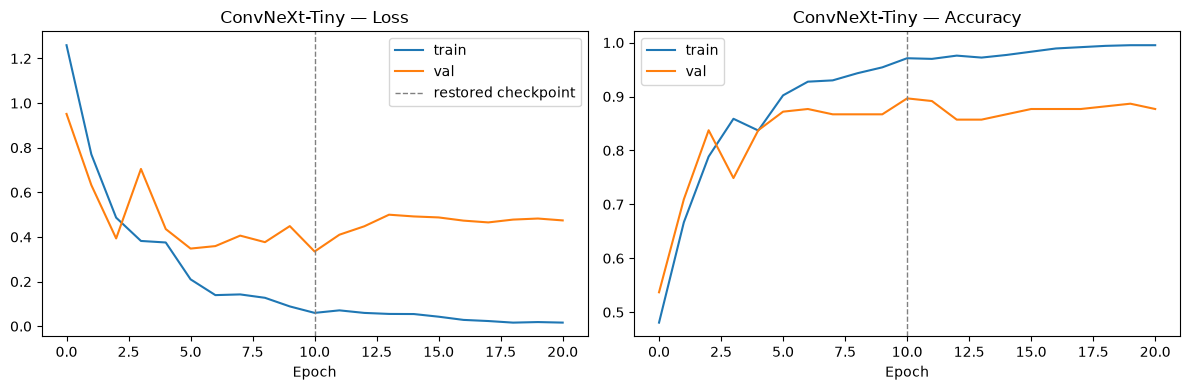

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ConvNeXt-Tiny", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ConvNeXt-Tiny")

## Evaluate on the test set

[ConvNeXt-Tiny] Test accuracy: 0.740


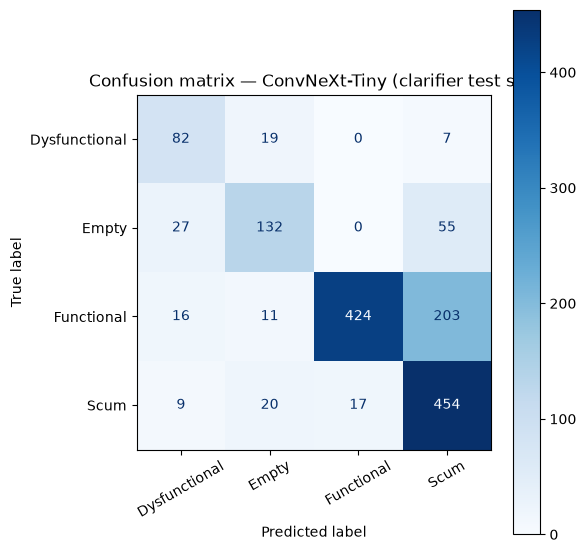

               precision    recall  f1-score   support

Dysfunctional      0.612     0.759     0.678       108
        Empty      0.725     0.617     0.667       214
   Functional      0.961     0.648     0.774       654
         Scum      0.631     0.908     0.745       500

     accuracy                          0.740      1476
    macro avg      0.733     0.733     0.716      1476
 weighted avg      0.790     0.740     0.742      1476



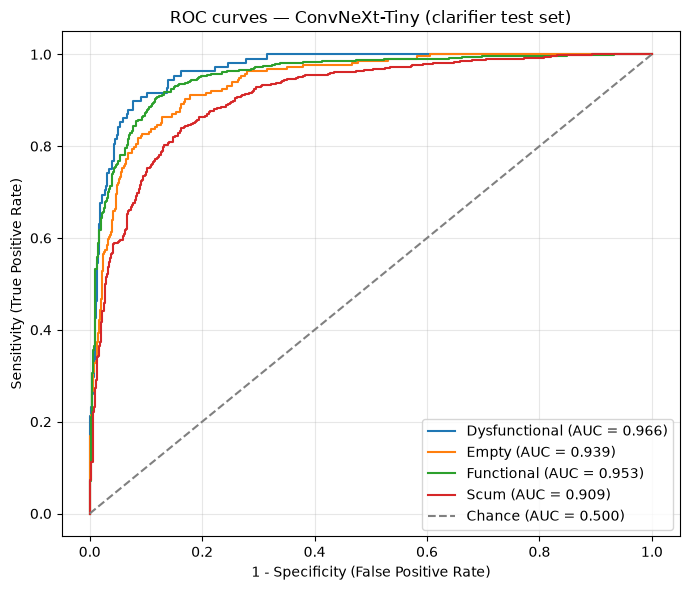

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.966
  Empty          : 0.939
  Functional     : 0.953
  Scum           : 0.909

Mean AUC (over 4/4 classes with test examples): 0.942


(np.float64(0.7398373983739838),
 {'Dysfunctional': 0.9664622590426684,
  'Empty': 0.9387376512582016,
  'Functional': 0.953373215175934,
  'Scum': 0.909358606557377})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ConvNeXt-Tiny", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("ConvNeXt-Tiny", "convnext_tiny")

Saved results to ../results/results_clarifier_convnext_tiny_CapeFlats.pkl
Saved model weights to ../models/clarifier_convnext_tiny_cnn.pt
